# 📊 Notebook 1 — Exploratory Data Analysis (EDA)
Dataset: Agro-Environmental Dataset  
Target: `failure_flag` — Klasifikasi apakah suatu lokasi pertanian mengalami kegagalan atau tidak.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../dataset/agro_environmental_dataset.csv')
print("Shape:", df.shape)
print("\nKolom:", df.columns.tolist())


Shape: (543210, 25)

Kolom: ['location_id', 'soil_type', 'bulk_density', 'organic_matter_pct', 'cation_exchange_capacity', 'salinity_ec', 'buffering_capacity', 'soil_moisture_pct', 'moisture_limit_dry', 'moisture_limit_wet', 'moisture_regime', 'soil_temp_c', 'air_temp_c', 'thermal_regime', 'light_intensity_par', 'soil_ph', 'ph_stress_flag', 'nitrogen_ppm', 'phosphorus_ppm', 'potassium_ppm', 'nutrient_balance', 'plant_category', 'suitability_score', 'stress_level', 'failure_flag']


## 1. Informasi Umum Dataset

In [9]:
print("=== Info Dataset ===")
df.info()


=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543210 entries, 0 to 543209
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   location_id               543210 non-null  object 
 1   soil_type                 543210 non-null  object 
 2   bulk_density              543210 non-null  float64
 3   organic_matter_pct        543210 non-null  float64
 4   cation_exchange_capacity  543210 non-null  int64  
 5   salinity_ec               543210 non-null  float64
 6   buffering_capacity        543210 non-null  float64
 7   soil_moisture_pct         543210 non-null  float64
 8   moisture_limit_dry        543210 non-null  int64  
 9   moisture_limit_wet        543210 non-null  int64  
 10  moisture_regime           543210 non-null  object 
 11  soil_temp_c               543210 non-null  float64
 12  air_temp_c                543210 non-null  float64
 13  thermal_regime         

In [10]:
print("=== 5 Baris Pertama ===")
df.head()


=== 5 Baris Pertama ===


,location_id,soil_type,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,...,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,nutrient_balance,plant_category,suitability_score,stress_level,failure_flag
0,L00000,Clayey,1.1,4.0,30,0.5,0.9,5.17,25,52,...,6.48,0,100.1,50.8,121.3,excessive,vegetable,0.677,1,0
1,L00001,Alluvial,1.3,3.8,20,0.4,0.7,26.28,16,45,...,6.43,0,133.8,54.9,151.6,optimal,vegetable,0.871,0,0
2,L00002,Chalky,1.5,2.0,8,0.3,0.4,44.90,12,35,...,5.01,1,84.5,83.6,83.6,deficient,vegetable,0.000,2,1
3,L00003,Silty,1.4,3.0,18,0.4,0.6,27.05,18,42,...,5.41,1,168.2,30.5,220.0,deficient,cereal,0.510,1,0
4,L00004,Loamy,1.3,3.5,15,0.3,0.7,36.56,15,40,...,6.73,0,98.9,63.4,88.9,optimal,vegetable,1.000,0,0


In [11]:
print("=== Statistik Deskriptif ===")
df.describe()


=== Statistik Deskriptif ===


,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,soil_temp_c,air_temp_c,light_intensity_par,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,suitability_score,stress_level,failure_flag
count,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000
mean,1.319365,4.000303,17.212248,0.673847,0.610260,34.977238,16.945798,42.566326,25.003662,28.007091,699.682397,6.499156,0.206417,100.369819,50.593494,110.290247,0.613343,0.914698,0.162147
std,0.243070,4.278072,10.367455,0.986025,0.198579,11.927853,6.615230,9.681918,4.991071,5.379043,288.943448,0.892323,0.404734,39.138892,23.827609,43.769883,0.246283,0.743454,0.368586
min,0.700000,1.200000,5.000000,0.200000,0.300000,5.000000,8.000000,28.000000,10.000000,7.000000,200.000000,4.000000,0.000000,20.000000,10.000000,20.000000,0.000000,0.000000,0.000000
25%,1.300000,1.800000,8.000000,0.300000,0.400000,26.870000,12.000000,38.000000,21.600000,24.400000,450.000000,5.890000,0.000000,73.000000,33.100000,79.700000,0.457000,0.000000,0.000000
50%,1.300000,3.500000,15.000000,0.400000,0.700000,34.970000,16.000000,42.000000,25.000000,28.000000,699.000000,6.500000,0.000000,100.000000,50.100000,110.000000,0.628000,1.000000,0.000000
75%,1.500000,3.800000,20.000000,0.500000,0.700000,43.070000,22.000000,45.000000,28.400000,31.600000,949.000000,7.110000,0.000000,127.000000,66.900000,140.300000,0.784000,1.000000,0.000000
max,1.600000,18.000000,40.000000,4.000000,0.900000,70.000000,30.000000,65.000000,40.000000,49.600000,1200.000000,8.800000,1.000000,220.000000,159.000000,220.000000,1.000000,2.000000,1.000000


## 2. Cek Missing Values & Duplikat

In [12]:
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing values")

print("\n=== Duplikat ===")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")


=== Missing Values ===
Tidak ada missing values

=== Duplikat ===
Jumlah baris duplikat: 0


## 3. Distribusi Target (failure_flag)

=== Distribusi Target ===
               Count  Percentage
failure_flag                    
0             455130       83.79
1              88080       16.21


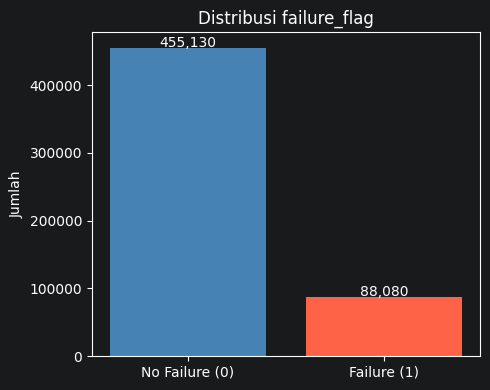

⚠ Dataset IMBALANCED — kelas 0 jauh lebih dominan dari kelas 1


In [13]:
counts = df['failure_flag'].value_counts()
pct = df['failure_flag'].value_counts(normalize=True) * 100
print("=== Distribusi Target ===")
print(pd.DataFrame({'Count': counts, 'Percentage': pct.round(2)}))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['No Failure (0)', 'Failure (1)'], counts.values, color=['steelblue', 'tomato'])
ax.set_title('Distribusi failure_flag')
ax.set_ylabel('Jumlah')
for i, v in enumerate(counts.values):
    ax.text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print("⚠ Dataset IMBALANCED — kelas 0 jauh lebih dominan dari kelas 1")


## 4. Distribusi Fitur Numerik

Fitur numerik: ['bulk_density', 'organic_matter_pct', 'cation_exchange_capacity', 'salinity_ec', 'buffering_capacity', 'soil_moisture_pct', 'moisture_limit_dry', 'moisture_limit_wet', 'soil_temp_c', 'air_temp_c', 'light_intensity_par', 'soil_ph', 'ph_stress_flag', 'nitrogen_ppm', 'phosphorus_ppm', 'potassium_ppm', 'suitability_score', 'stress_level']
Jumlah fitur numerik: 18


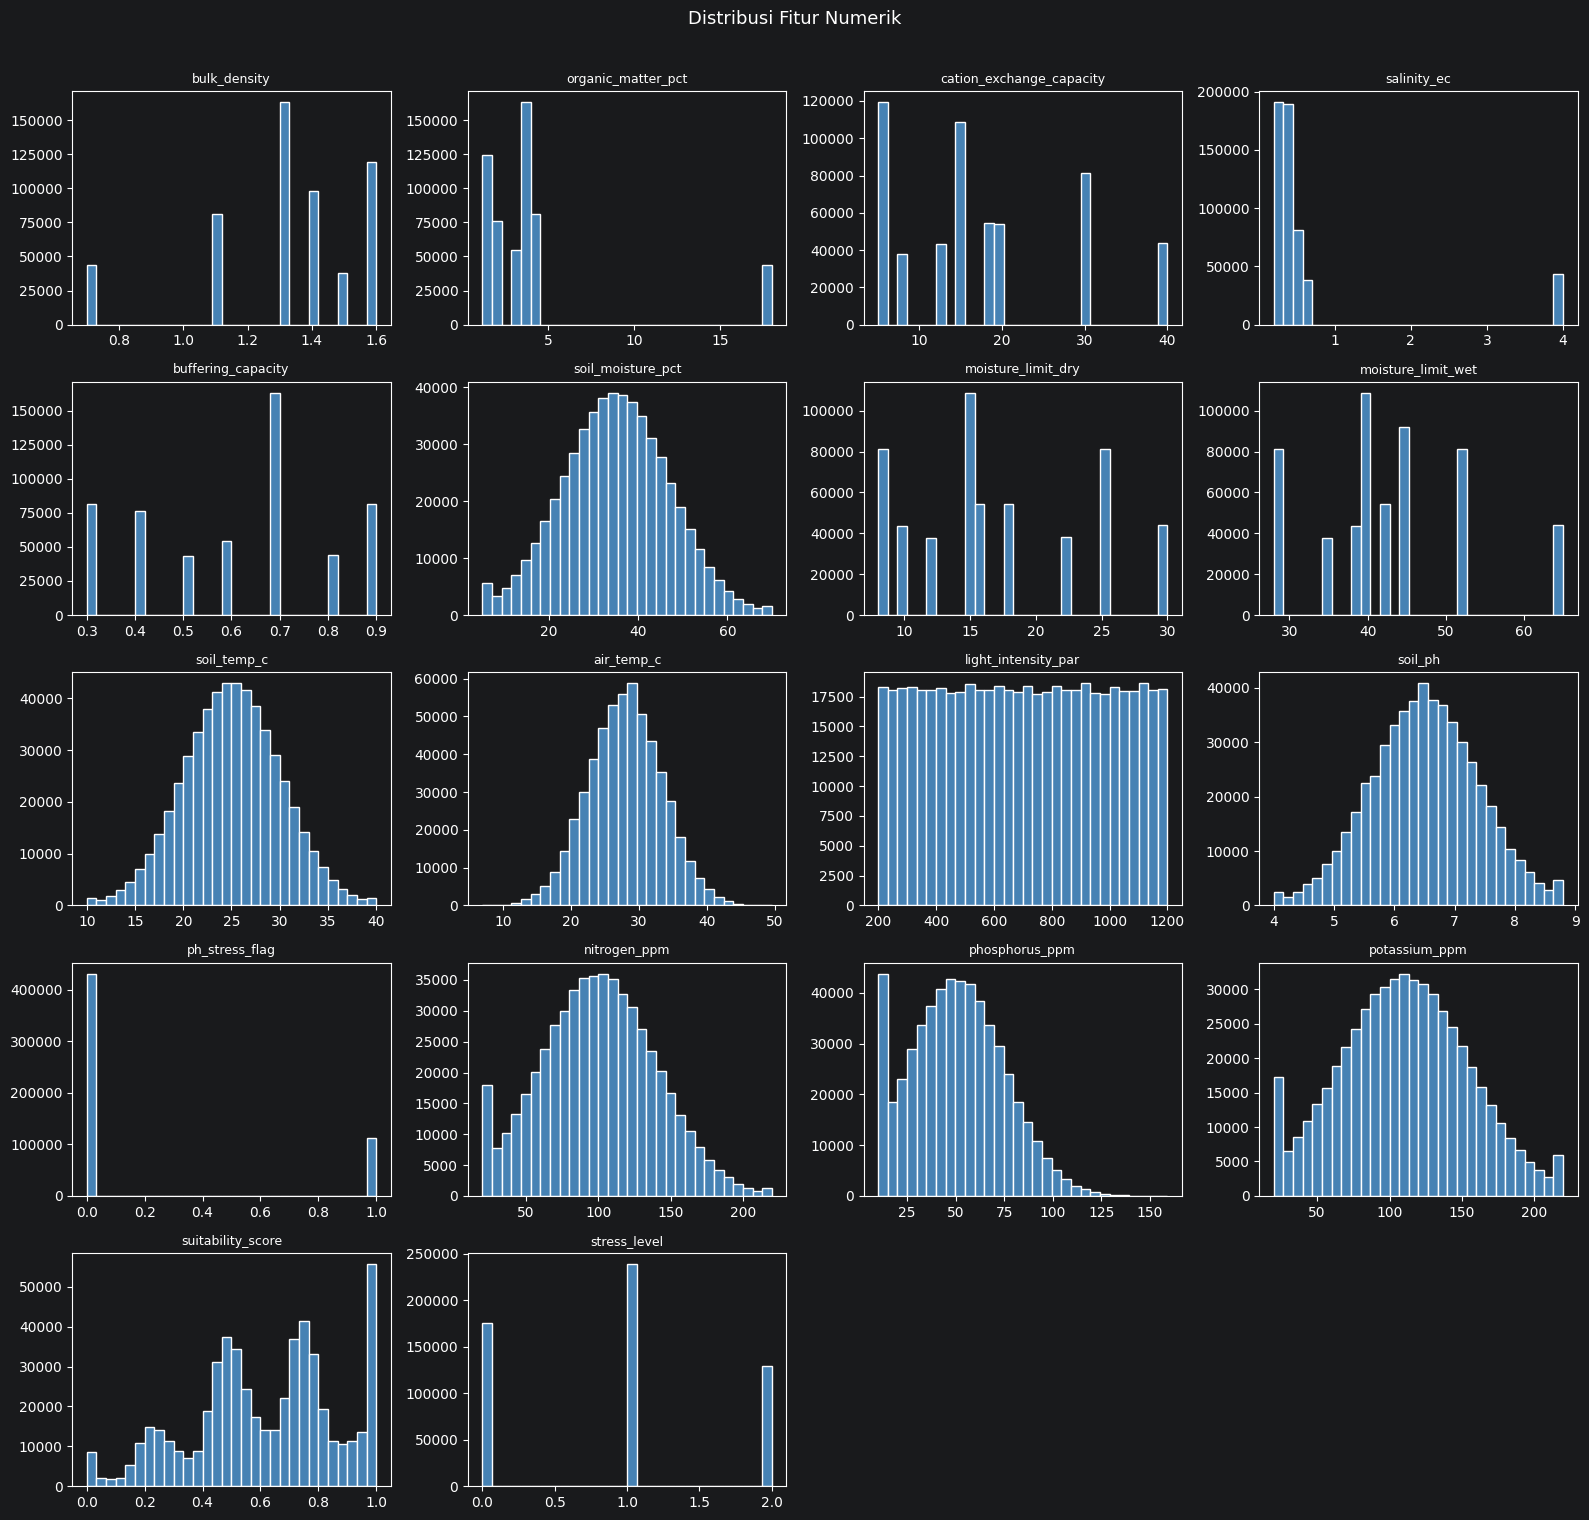

In [14]:
num_cols = df.select_dtypes(include='number').columns.drop('failure_flag').tolist()
print("Fitur numerik:", num_cols)
print("Jumlah fitur numerik:", len(num_cols))

# Hitung grid secara dinamis
n_cols = 4
n_rows = -(-len(num_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
for j in range(len(num_cols), len(axes)):  # sembunyikan axes kosong
    axes[j].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 5. Distribusi Fitur Kategorikal

Fitur kategorikal: ['soil_type', 'moisture_regime', 'thermal_regime', 'nutrient_balance', 'plant_category']


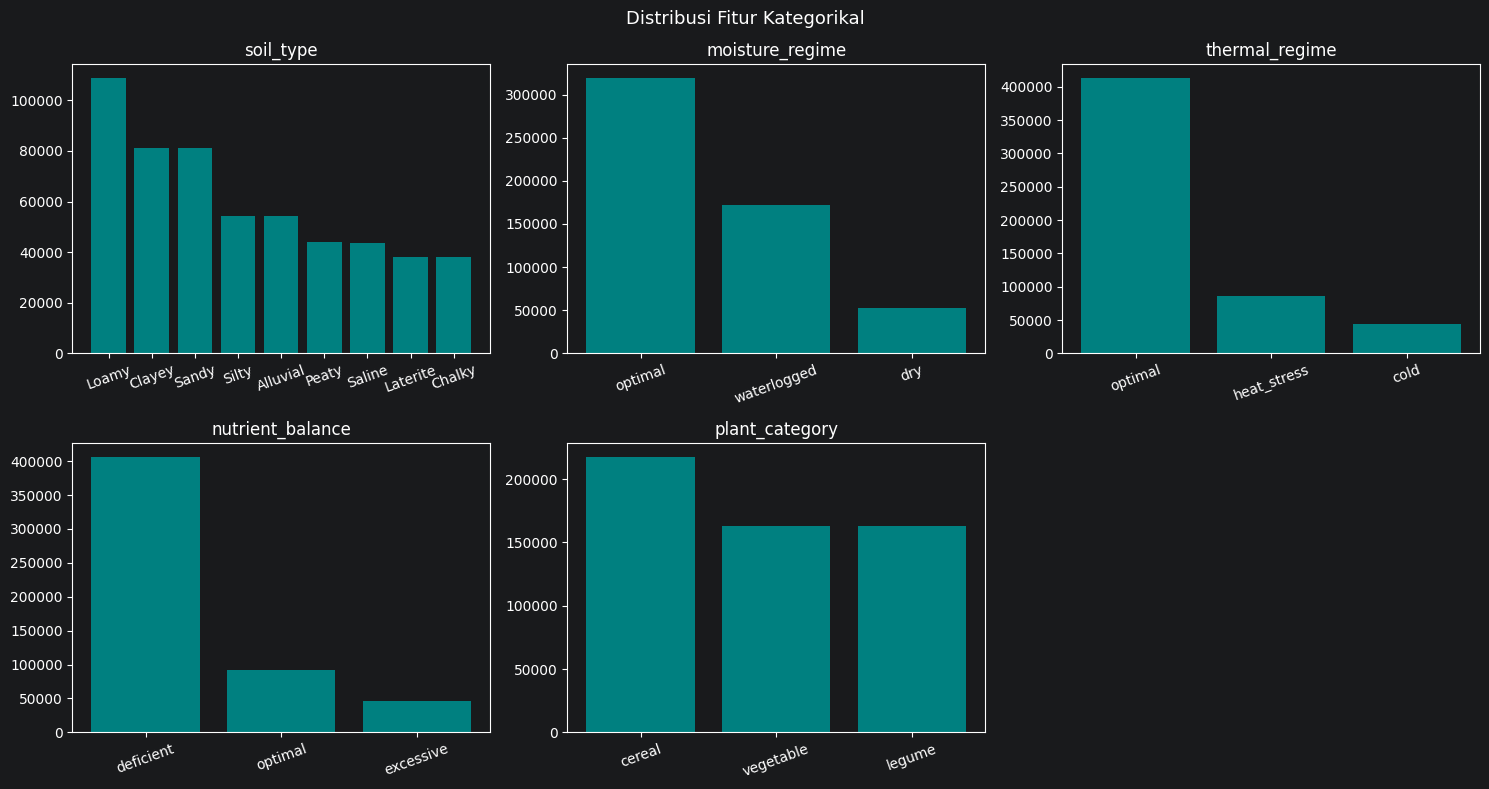

In [15]:
cat_cols = ['soil_type', 'moisture_regime', 'thermal_regime', 'nutrient_balance', 'plant_category']
print("Fitur kategorikal:", cat_cols)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color='teal')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=20)
axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur Kategorikal', fontsize=13)
plt.tight_layout()
plt.show()


## 6. Korelasi Antar Fitur Numerik (Heatmap)

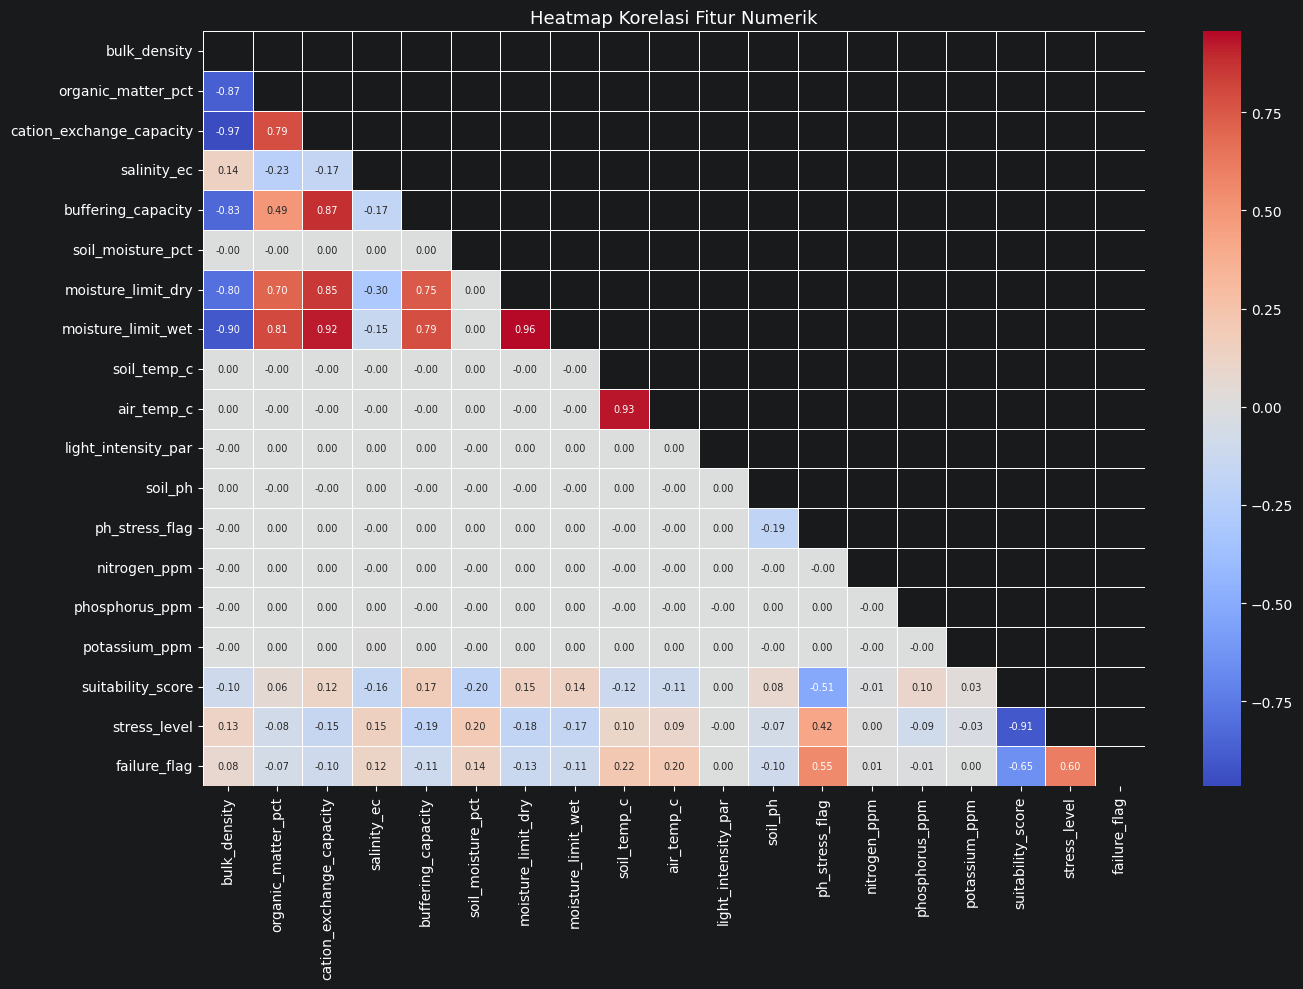

In [16]:
corr_cols = num_cols + ['failure_flag']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=13)
plt.tight_layout()
plt.show()


## 7. Korelasi Terhadap Target

=== Korelasi Fitur terhadap failure_flag ===
suitability_score          -0.6458
moisture_limit_dry         -0.1280
moisture_limit_wet         -0.1120
buffering_capacity         -0.1090
soil_ph                    -0.0991
cation_exchange_capacity   -0.0977
organic_matter_pct         -0.0696
phosphorus_ppm             -0.0098
light_intensity_par         0.0008
potassium_ppm               0.0011
nitrogen_ppm                0.0095
bulk_density                0.0848
salinity_ec                 0.1168
soil_moisture_pct           0.1370
air_temp_c                  0.2010
soil_temp_c                 0.2164
ph_stress_flag              0.5521
stress_level                0.6036
Name: failure_flag, dtype: float64


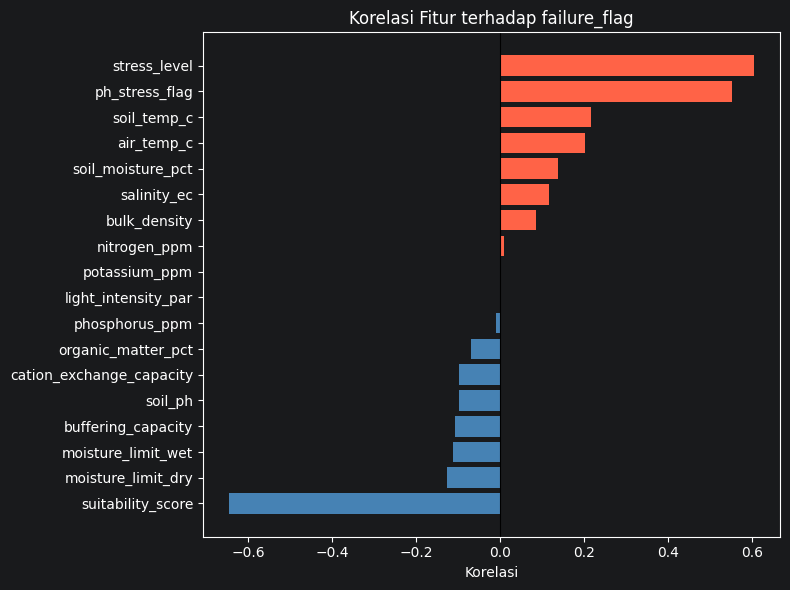

In [17]:
corr_target = df[corr_cols].corr()['failure_flag'].drop('failure_flag').sort_values()
print("=== Korelasi Fitur terhadap failure_flag ===")
print(corr_target.round(4))

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if c > 0 else 'steelblue' for c in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Korelasi Fitur terhadap failure_flag')
ax.set_xlabel('Korelasi')
plt.tight_layout()
plt.show()


## 8. Boxplot Fitur Numerik vs Target

Top 6 fitur berkorelasi dengan target: ['suitability_score', 'stress_level', 'ph_stress_flag', 'soil_temp_c', 'air_temp_c', 'soil_moisture_pct']


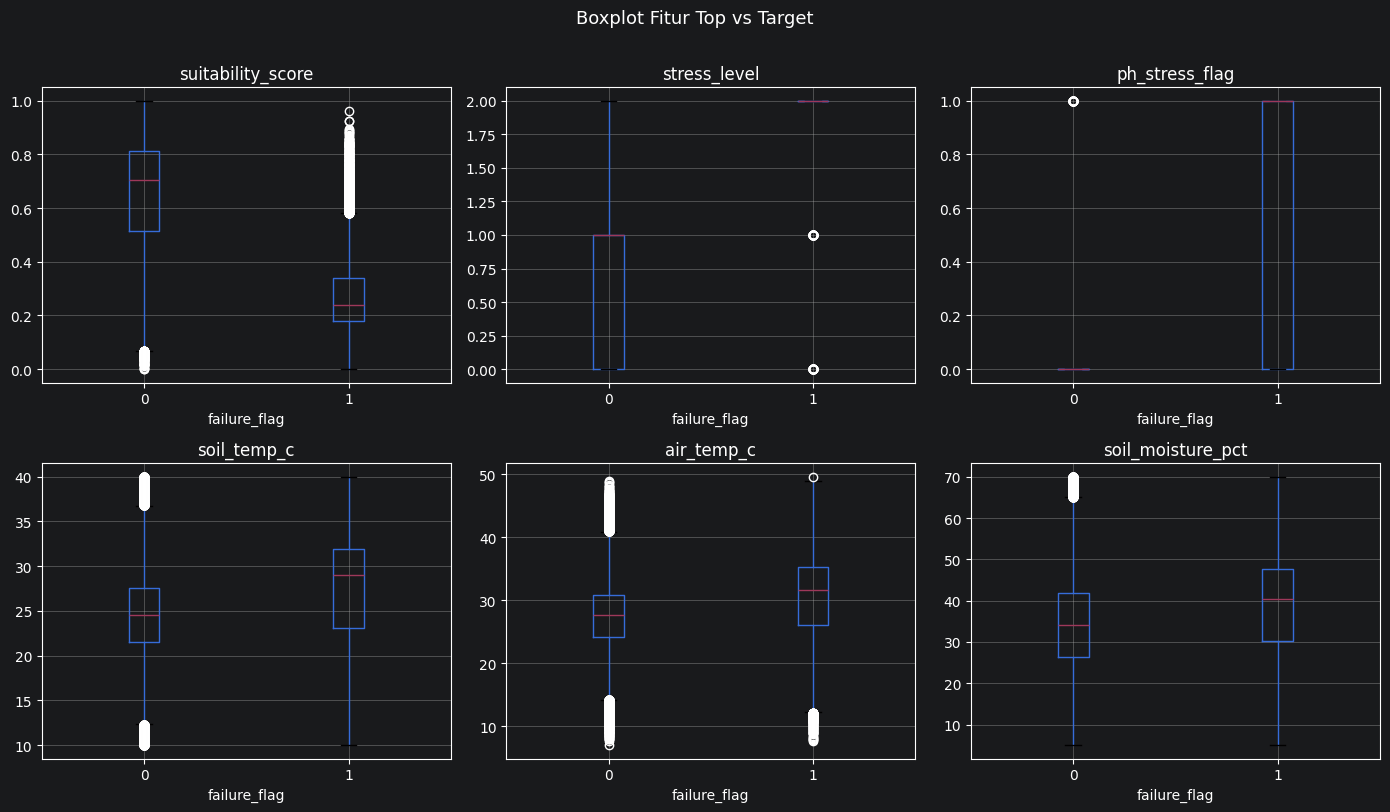

In [18]:
top_feats = corr_target.abs().sort_values(ascending=False).head(6).index.tolist()
print("Top 6 fitur berkorelasi dengan target:", top_feats)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(top_feats):
    df.boxplot(column=col, by='failure_flag', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('failure_flag')
plt.suptitle('')
plt.suptitle('Boxplot Fitur Top vs Target', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


## 9. Fitur Kategorikal vs Target (Failure Rate)


=== Failure Rate per soil_type ===
soil_type
Saline      0.3110
Sandy       0.2357
Chalky      0.1847
Loamy       0.1479
Silty       0.1388
Alluvial    0.1177
Laterite    0.1168
Clayey      0.1118
Peaty       0.1111
Name: failure_flag, dtype: float64

=== Failure Rate per moisture_regime ===
moisture_regime
waterlogged    0.3158
dry            0.1919
optimal        0.0747
Name: failure_flag, dtype: float64

=== Failure Rate per thermal_regime ===
thermal_regime
heat_stress    0.4801
cold           0.1879
optimal        0.0929
Name: failure_flag, dtype: float64

=== Failure Rate per nutrient_balance ===
nutrient_balance
deficient    0.2014
optimal      0.0545
excessive    0.0296
Name: failure_flag, dtype: float64

=== Failure Rate per plant_category ===
plant_category
cereal       0.1742
vegetable    0.1724
legume       0.1358
Name: failure_flag, dtype: float64


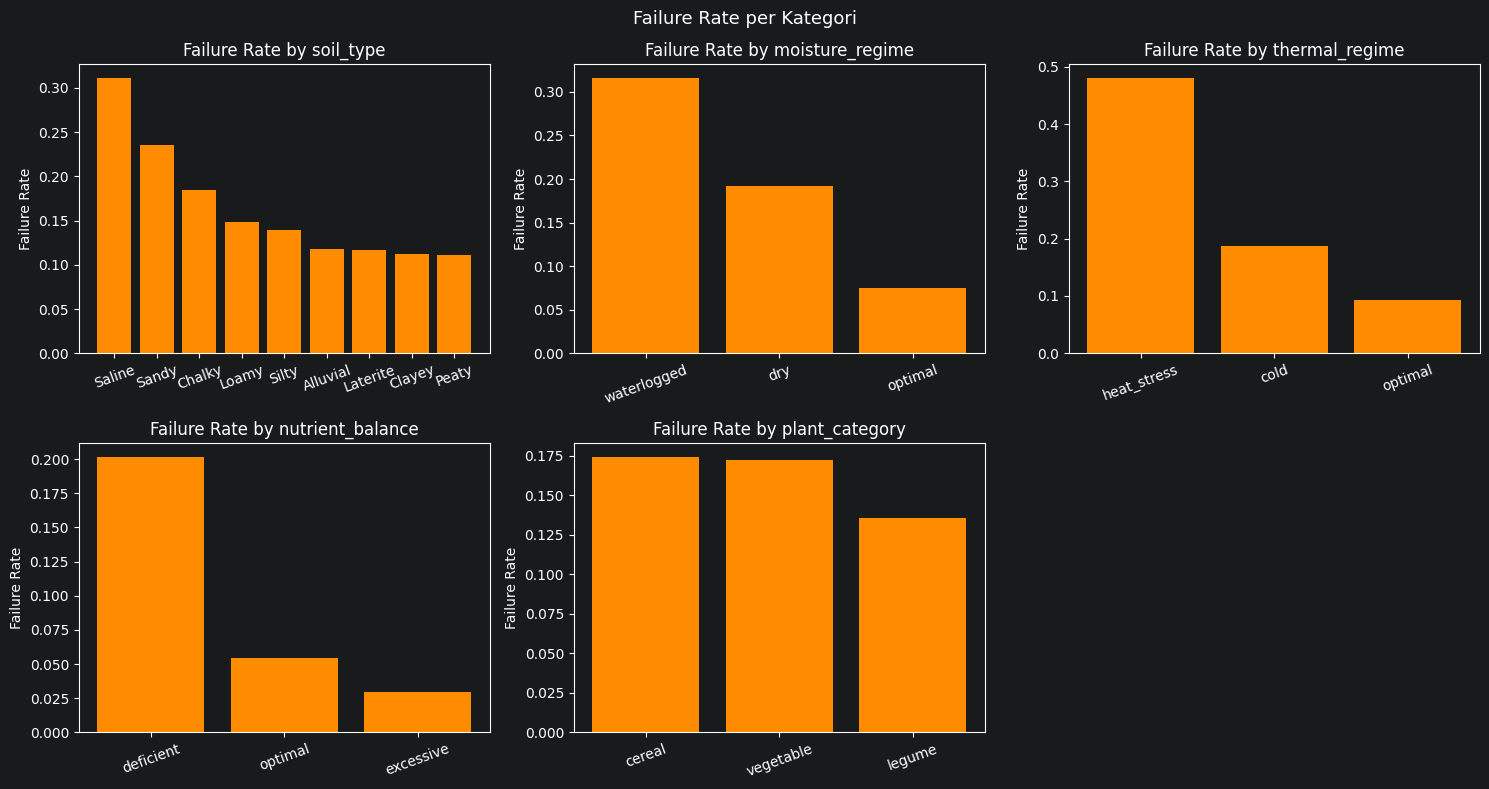

In [19]:
for col in cat_cols:
    rate = df.groupby(col)['failure_flag'].mean().sort_values(ascending=False)
    print(f"\n=== Failure Rate per {col} ===")
    print(rate.round(4))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['failure_flag'].mean().sort_values(ascending=False)
    axes[i].bar(rate.index, rate.values, color='darkorange')
    axes[i].set_title(f'Failure Rate by {col}')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].set_ylabel('Failure Rate')
axes[-1].set_visible(False)
plt.suptitle('Failure Rate per Kategori', fontsize=13)
plt.tight_layout()
plt.show()


## ✅ Ringkasan EDA
- Dataset berisi **543.210 baris** dan **25 kolom**
- **Tidak ada missing values** dan **tidak ada duplikat**
- Target `failure_flag`: **imbalanced** (~83.8% kelas 0 vs ~16.2% kelas 1) → perlu teknik oversampling/undersampling
- Beberapa fitur numerik memiliki korelasi signifikan dengan target
- Fitur `location_id` bersifat ID unik dan harus di-drop saat preprocessing
